In [1]:
import sys
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [2]:
# Import necessary libraries
import pandas as pd
import re
import ast
import matplotlib.pyplot as plt


## Load and Inspect the Data

In [3]:
# Import HUMMUS dataset

df = pd.read_csv('../data/pp_recipes.csv')

/tmp/ipykernel_3780442/3480901654.py:3: DtypeWarning: Columns (35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/pp_recipes.csv')


In [4]:
df.shape

(507335, 37)

In [5]:
df.columns

Index(['Unnamed: 0', 'recipe_id', 'title', 'description', 'author_id',
       'duration', 'directions', 'ingredients', 'serves', 'last_changed_date',
       'food_kg_locator', 'recipe_url', 'tags', 'new_recipe_id',
       'new_author_id', 'average_rating', 'number_of_ratings',
       'servingsPerRecipe', 'servingSize [g]', 'calories [cal]',
       'caloriesFromFat [cal]', 'totalFat [g]', 'saturatedFat [g]',
       'cholesterol [mg]', 'sodium [mg]', 'totalCarbohydrate [g]',
       'dietaryFiber [g]', 'sugars [g]', 'protein [g]', 'direction_size',
       'ingredients_sizes', 'who_score', 'fsa_score', 'nutri_score',
       'normalization_comment', 'ingredient_food_kg_urls',
       'ingredient_food_kg_names'],
      dtype='object')

### Distribution of all recipes per nutri-score

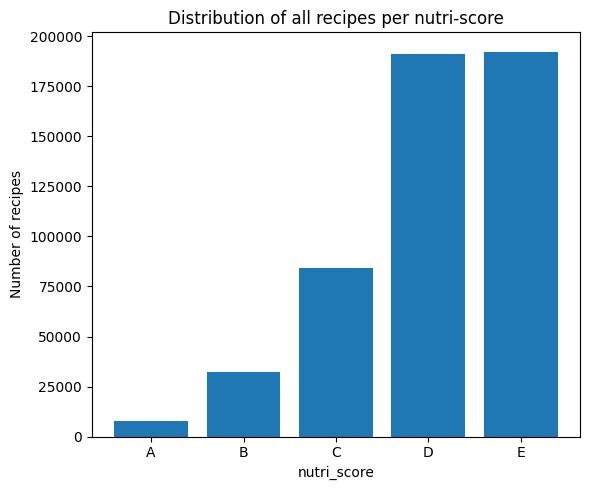

In [6]:
# Map numeric nutri_score values to letter grades for plotting
nutri_mapping = {1.00: 'A', 0.75: 'B', 0.50: 'C', 0.25: 'D', 0.00: 'E'}
nutri_grades = df['nutri_score'].round(2).map(nutri_mapping)
nutri_counts = nutri_grades.value_counts().reindex(list('ABCDE'), fill_value=0)

plt.figure(figsize=(6, 5))
plt.bar(nutri_counts.index, nutri_counts.values)
plt.title('Distribution of all recipes per nutri-score')
plt.xlabel('nutri_score')
plt.ylabel('Number of recipes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
# Drop unnecessary columns

df.drop(['recipe_id', 'Unnamed: 0', 'description','serves',  'author_id','tags', 'last_changed_date','food_kg_locator', 'recipe_url', 'new_recipe_id', 'new_author_id', 'average_rating', 'number_of_ratings','normalization_comment', 'ingredient_food_kg_urls',
       'ingredient_food_kg_names'], axis=1, inplace=True)


## Curate Missing Values

In [8]:
# Check for missing values

df.isna().sum()

title                        0
duration                  7338
directions                   0
ingredients                  2
servingsPerRecipe            0
servingSize [g]              0
calories [cal]               0
caloriesFromFat [cal]        0
totalFat [g]                 0
saturatedFat [g]             0
cholesterol [mg]             0
sodium [mg]                  0
totalCarbohydrate [g]        0
dietaryFiber [g]             0
sugars [g]                   0
protein [g]                  0
direction_size               0
ingredients_sizes            0
who_score                 1127
fsa_score                15504
nutri_score                  0
dtype: int64

In [9]:
# Drop rows with missing values

df.dropna(subset=["duration","ingredients"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [10]:
# Check the shape of df

df.shape

(499995, 21)

## Check Numerical Features

In [11]:
df.dtypes

title                     object
duration                 float64
directions                object
ingredients               object
servingsPerRecipe          int64
servingSize [g]          float64
calories [cal]           float64
caloriesFromFat [cal]    float64
totalFat [g]             float64
saturatedFat [g]         float64
cholesterol [mg]         float64
sodium [mg]              float64
totalCarbohydrate [g]    float64
dietaryFiber [g]         float64
sugars [g]               float64
protein [g]              float64
direction_size             int64
ingredients_sizes          int64
who_score                float64
fsa_score                float64
nutri_score              float64
dtype: object

## Directions

In [12]:
# Check the data type 

print(df['directions'][0])
print(df['directions'].dtype)
print(type((df['directions'][0])))

['Preheat oven to 275 degrees. In a very large bowl combine the popped popcorn, cranberries and almonds; set aside.', 'In a 2-quart saucepan cook and stir the butter, brown sugar and corn syrup over medium heat until butter is melted.', 'Stir in orange juice. Bring to boiling over medium heat.', 'Boil at a moderate, steady rate for 2 minutes.', 'Remove from heat. Stir in vanilla and baking soda (mixture will foam up).', 'Pour the syrup mixture over the popcorn mixture in bowl; stir to coat well.', 'Transfer to a 15x10x1 inch baking pan or shallow raosting pan.', 'Bake for 30 minutes, stirring twice.', 'Transfer caramel corn to a large sheet of greased heavy foil; cool.']
object
<class 'str'>


In [13]:
# Convert directions into list of strings

df['directions'] = df['directions'].apply(ast.literal_eval)
type((df['directions'][0]))

list

In [14]:
# Check length of directions / directions_size column - keep this column for now

print(len(df['directions'][0]))
print(df['direction_size'][0])

9
9


In [15]:
is_all_lists = df['directions'].apply(lambda x: isinstance(x, list)).all()
print(is_all_lists)  # True/False


True


## Ingredients

In [16]:
# Check the ingredients column

df['ingredients']

0         {'': [('popcorn, popped', '12  time(s) cups ')...
1         {'': [('shelled and cooked shrimp (50-60 count...
2         {'': [('cream', '200  time(s) g '), ('vanilla ...
3         {'': [('of lamb', '6  time(s) lbs leg '), ('dr...
4         {'': [('egg, beaten', '1  time(s) '), ('toaste...
                                ...                        
499990    {'filling': [('dark corn syrup', '/ time(s) cu...
499991    {'': [('oil', '5  time(s) tablespoons '), ('gr...
499992    {'': [('boneless skinless chicken breasts, cub...
499993    {'': [('wonton wrappers (about 48)', '12  time...
499994    {'': [('chunk light tuna, drained well', '4 ti...
Name: ingredients, Length: 499995, dtype: object

In [17]:
# Function to extract ingredient names and measurements
def extract_ingredients(ingredient_str):
    ingredients_dict = ast.literal_eval(ingredient_str)
    
    ingredient_names = []
    measurements = []
    
    for category, items in ingredients_dict.items():
        for item in items:
            ingredient_names.append(item[0])
            measurements.append(item[1])
    
    return ingredient_names, measurements


In [18]:
# Apply the function to the 'ingredients' column and create ingredient_names and measurements columns

df[['ingredient_names', 'measurements']] = df['ingredients'].apply(lambda x: pd.Series(extract_ingredients(x)))

In [19]:
# Drop the original ingredients column
df.drop('ingredients', axis=1, inplace=True)

In [20]:
# Check ingredient sizes column / keep it for now

print(df['ingredients_sizes'].dtype)
print(len(df.iloc[0]['ingredient_names']))
print(df.iloc[0]['ingredients_sizes'])

int64
9
9


### Ingredient names

In [21]:
# Check ingredient names

df['ingredient_names']

0         [popcorn, popped, dried cranberries, whole alm...
1         [shelled and cooked shrimp (50-60 count is goo...
2         [cream, vanilla bean, sugar, yolks, gelatin, c...
3         [of lamb, dried mint flakes, dried rosemary, d...
4         [egg, beaten, toasted sesame oil, soy sauce, f...
                                ...                        
499990    [dark corn syrup, firmly packed brown sugar, e...
499991    [oil, green onion, chopped fine, pork, minced,...
499992    [boneless skinless chicken breasts, cubed (or ...
499993    [wonton wrappers (about 48), ground pork, egg,...
499994    [chunk light tuna, drained well, artichoke hea...
Name: ingredient_names, Length: 499995, dtype: object

In [22]:
# Check data type of ingredient names (should be a list)

print(type(df['ingredient_names'][0]))
print(df['ingredient_names'][0][0]) # each ingredient is an item in the list

<class 'list'>
popcorn, popped


In [23]:
# Check for only string ingredient_names

non_string_items = []

for idx, ingredients in enumerate(df['ingredient_names']):
    if isinstance(ingredients, list):
        for item in ingredients:
            if not isinstance(item, str):
                non_string_items.append((idx, item, type(item)))

for idx, item, item_type in non_string_items:
    print(f"Row {idx}: Non-string item: {item} (type: {item_type})")

if not non_string_items:
    print("All items in 'ingredient_names' are strings.")


Row 55814: Non-string item: 1.0 (type: <class 'float'>)
Row 447353: Non-string item: 5.0 (type: <class 'float'>)


In [24]:
# Manually drop these rows
df.drop([55814, 447353], inplace=True)


In [25]:
# Evaluate the unique ingredients of the dataset

unique_ingredients = set()

for ingredients in df['ingredient_names']:
    # assuming each 'ingredients' is already a list of strings
    unique_ingredients.update(ingredients)

unique_ingredients = sorted(unique_ingredients)

In [26]:
# Check the number of unique ingredients

len(unique_ingredients)

764863

In [27]:
unique_ingredients

['!)',
 '#133675',
 '#134704',
 '$notetemplate1$',
 '$notetemplate1$)',
 '$notetemplate1$-inch to make veggie salmon',
 '$template2$',
 '$template2$ ((See note below on tomatoes.))',
 '$template2$ (*for variation, try using cilantro in place of the oregano)',
 '$template2$ (1 cup combination nuts) or 1 cup almonds (1 cup combination nuts)',
 '$template2$ (1 large bunch)',
 '$template2$ (1 package or about 4 ears or 1 can) or 2 cups $template3$ (1 package or about 4 ears or 1 can)',
 '$template2$ (1 tbsp fresh = 1 tsp dried) or $template3$, cut finely',
 '$template2$ (1 to 1 1/2 inches thick) or 1 1/4 lbs other thick white fish fillets, cut into 4 pieces (1 to 1 1/2 inches thick)',
 '$template2$ (1 tsp. if dried) or 1 tablespoon $template3$ (1 tsp. if dried)',
 '$template2$ (1-inch chunks) or 4 cups $template3$ (1-inch chunks)',
 '$template2$ (1/2 cup) or 2 ounces $template3$ (1/2 cup)',
 '$template2$ (1/2 halved or 1/4 if large)',
 '$template2$ (1/2 pint) or 300 ml $template3$ (1/2 pin

In [28]:
# Search for problematic or inconsistent entries in ingredient names

# Define a pattern: anything NOT a-z, A-Z, 0-9, space, comma, or parentheses
pattern = re.compile(r'[^a-zA-Z0-9\s,()<>-]')

def is_parenthetical(ing: str) -> bool:
    stripped = ing.strip().strip("\"'").strip()
    return (
        stripped.startswith('(')
        and stripped.endswith(')')
        and len(stripped) > 2
    )

incosistent_ingredients = [
    ing for ing in unique_ingredients
    if (
        '$template' in ing.lower()
        or pattern.search(ing)
        or is_parenthetical(ing)
    )
]


# Check the number of inconsistent ingredients
len(incosistent_ingredients)


148797

In [29]:
# Check the inconsistent ingredients

incosistent_ingredients

['!)',
 '#133675',
 '#134704',
 '$notetemplate1$',
 '$notetemplate1$)',
 '$notetemplate1$-inch to make veggie salmon',
 '$template2$',
 '$template2$ ((See note below on tomatoes.))',
 '$template2$ (*for variation, try using cilantro in place of the oregano)',
 '$template2$ (1 cup combination nuts) or 1 cup almonds (1 cup combination nuts)',
 '$template2$ (1 large bunch)',
 '$template2$ (1 package or about 4 ears or 1 can) or 2 cups $template3$ (1 package or about 4 ears or 1 can)',
 '$template2$ (1 tbsp fresh = 1 tsp dried) or $template3$, cut finely',
 '$template2$ (1 to 1 1/2 inches thick) or 1 1/4 lbs other thick white fish fillets, cut into 4 pieces (1 to 1 1/2 inches thick)',
 '$template2$ (1 tsp. if dried) or 1 tablespoon $template3$ (1 tsp. if dried)',
 '$template2$ (1-inch chunks) or 4 cups $template3$ (1-inch chunks)',
 '$template2$ (1/2 cup) or 2 ounces $template3$ (1/2 cup)',
 '$template2$ (1/2 halved or 1/4 if large)',
 '$template2$ (1/2 pint) or 300 ml $template3$ (1/2 pin

In [30]:
# Remove rows with incosistent ingredients (temporary solution)

# Convert your special_ingredients list to a set for fast lookup
incosistent_set = set(incosistent_ingredients)

# Define the updated function using the set
def has_special_ingredient(ingredients):
    # Safely check: ingredients should be a list; skip if it's not
    if not isinstance(ingredients, list):
        return False
    return any(ing in incosistent_set for ing in ingredients)

# Filter the dataframe (this keeps only rows WITHOUT special ingredients)
df = df[~df['ingredient_names'].apply(has_special_ingredient)]


In [31]:
unique_ingredients = sorted(
    {ing for ingredients in df['ingredient_names'] if isinstance(ingredients, list)
     for ing in ingredients}
)

In [32]:
# Check the shape of df after dropping rows with inconsistent ingredients

df.shape

(330512, 22)

In [33]:
len(unique_ingredients)

410404

### Measurements

In [34]:
# Clean up measurements column

df['measurements'] = df['measurements'].apply(
    lambda x: [s.replace(' time(s)', '').replace('/ ', ' 1/2 ').strip() for s in x]
)

In [35]:
# Check data type of measurements

print(type(df['measurements'][0]))
print(df['measurements'][0][0]) # each measurement is an item in the list

<class 'list'>
12  cups


In [36]:
# Take a look at measurements unique values

# Flatten all lists and extract unique measurement strings
set(val for sublist in df['measurements'] for val in sublist)

{'',
 '2 (150 g) medium egg',
 '1 (120 g) package chicken stuffing',
 '2  small sweet potatoes (between 5 and 6 ounces',
 '2  slices jarlsberg',
 '4  ounces sliced water chestnuts, drained (these are in a can',
 '24  ravioli, squares (about 48 if using',
 '4  lasagna noodles, cooked according',
 '12 (1 3/4 ounce)',
 '400  g vegetables (you can',
 '2  cups mashed sweet potatoes (you can',
 'water, for the roasting',
 '32  ounces sour cream (can',
 '1 (2 1/2 kg)',
 '2 lbs steak, sliced into strips you can',
 '0.3333333333333333 teaspoon dried oregano, Mexican',
 '2  teaspoons fresh thyme, finely chopped (or 1 teaspoon',
 '1 (577 g) package swiss chocolate cake mix (Duncan',
 '1 (3/4 ounce) packet honey mustard salad dressing',
 '1 1/2 liters strong',
 '5  ounces about 1/2 soup can',
 '2  acorn squash (about 2 to 2 1/2 pounds',
 '1  stalk celery, cut up in big',
 '1 (16 ounce) peaches (lite and cut into bite size pieces leaving',
 'butter, for coating',
 '3 1/2 cups cream, 1/2 cup',
 '1 -

## Remove duplicate Recipes

In [37]:
df['title'].value_counts().gt(1).sum()

np.int64(20041)

In [38]:
df = df.drop_duplicates(subset=['title']).reset_index(drop=True)

In [39]:
df[df.duplicated(subset="title", keep=False)]

,title,duration,directions,servingsPerRecipe,servingSize [g],calories [cal],caloriesFromFat [cal],totalFat [g],saturatedFat [g],cholesterol [mg],...,dietaryFiber [g],sugars [g],protein [g],direction_size,ingredients_sizes,who_score,fsa_score,nutri_score,ingredient_names,measurements


In [40]:
df[df.duplicated(subset="title", keep=False)]

,title,duration,directions,servingsPerRecipe,servingSize [g],calories [cal],caloriesFromFat [cal],totalFat [g],saturatedFat [g],cholesterol [mg],...,dietaryFiber [g],sugars [g],protein [g],direction_size,ingredients_sizes,who_score,fsa_score,nutri_score,ingredient_names,measurements


In [41]:
df.shape

(281689, 22)

## Save the Proprocessed Dataset

In [ ]:
# Take a final look at the df

df.info()

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

In [ ]:
df.to_pickle("data/pp_recipes_preprocessed_v3.pkl")

## Tag and calculate weights (LLM - based)

In [ ]:
# In this step we calculated tags and weights ...

## Load Tagged and weighted Dataset

In [1]:
import pandas as pd

In [2]:
# Import HUMMUS dataset

df = pd.read_csv('../data/pp_recipes.csv')

/tmp/ipykernel_698518/3480901654.py:3: DtypeWarning: Columns (35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/pp_recipes.csv')


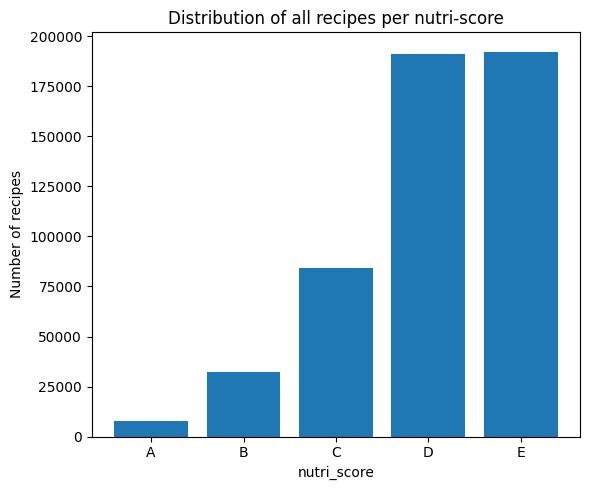

In [5]:
# Translate numeric nutri_score to letters and plot
nutri_mapping = {1.00: 'A', 0.75: 'B', 0.50: 'C', 0.25: 'D', 0.00: 'E'}
nutri_grades = df['nutri_score'].round(2).map(nutri_mapping)
nutri_counts = nutri_grades.value_counts().reindex(list('ABCDE'), fill_value=0)

plt.figure(figsize=(6, 5))
plt.bar(nutri_counts.index, nutri_counts.values)  # default blue bars
plt.title('Distribution of all recipes per nutri-score')
plt.xlabel('nutri_score')
plt.ylabel('Number of recipes')
plt.tight_layout()
plt.show()
